# IBEX 35 Volatility: Stage 4 — Value-at-Risk and Expected Shortfall

Stage 3 gave each index a preferred conditional-volatility model — GJR-GARCH
for the IBEX 35, EGARCH for the S&P 500 — validated by an ARCH-LM test
showing the volatility clustering had been absorbed. This notebook turns
those fitted models into the risk numbers a market-risk desk actually
consumes day to day: **Value-at-Risk (VaR)** and **Expected Shortfall (ES)**.

We compute both from the GARCH model directly, and alongside them a simple
**EWMA (RiskMetrics)** benchmark that uses no fitted model at all — the
question this notebook is really asking is *does the extra modelling effort
in Stage 3 buy us anything over the industry's oldest, simplest volatility
estimator?*

This notebook is self-contained: it re-downloads the same ~10y of daily data
and refits the Stage 3 preferred models from scratch.

**A scope caveat up front:** every model here is fit **once, on the full
sample**. That means the "conditional volatility" and VaR series below are
**in-sample** — they describe how well these models fit the data they were
estimated on, not how they would have performed in real time, since the
fitted parameters were informed by the entire series, including data from
after any given date $t$. Stage 5 repeats this exercise properly, with an
expanding-window backtest that refits the model using only data available at
each point in time. Treat this notebook as model exploration and a first,
informal look at breach counts — not a validated forecast.

**Goals of this notebook**
1. Compute dynamic, GARCH-based parametric VaR at 95% and 99%.
2. Compute Expected Shortfall at 97.5% (Basel FRTB) and 99%.
3. Compute an EWMA/RiskMetrics VaR baseline for a fair, apples-to-apples
   comparison against the GARCH model.
4. Compare breach counts across methods — a preview of the formal,
   out-of-sample backtests in Stage 5.


## 1. Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from arch import arch_model
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100


## 2. Data

Same construction as Stages 1-3: ~10 years of daily closes for the IBEX 35
(`^IBEX`) and S&P 500 (`^GSPC`), log returns scaled to percent.


In [2]:
TICKERS = {"IBEX35": "^IBEX", "SP500": "^GSPC"}
END = pd.Timestamp.today().normalize()
START = END - pd.DateOffset(years=10)

raw = yf.download(list(TICKERS.values()), start=START, end=END, auto_adjust=True, progress=False)
prices = raw["Close"].rename(columns={v: k for k, v in TICKERS.items()})
prices = prices.dropna(how="all").ffill().dropna()

returns_pct = 100 * np.log(prices / prices.shift(1)).dropna()
returns_pct.tail()


Ticker,SP500,IBEX35
Date,,
2026-07-07,-0.446506,-0.221756
2026-07-08,-0.282121,-2.766496
2026-07-09,0.810982,1.137230
2026-07-10,0.420001,0.319827
2026-07-13,-0.795861,-0.253097


## 3. Refit the Stage 3 preferred models

Stage 3 selected **GJR-GARCH(1,1,1)** for the IBEX 35 and **EGARCH(1,1)** for
the S&P 500 by AIC/BIC, both with a constant mean and Student-t innovations.
We refit exactly those specifications here (numbers may drift very slightly
from Stage 3's printed values, since this notebook re-downloads data as of
today rather than importing Stage 3's snapshot — a few additional trading
days will have accumulated).


In [3]:
preferred_spec = {
    "IBEX35": dict(vol="GARCH", p=1, o=1, q=1),   # GJR-GARCH
    "SP500": dict(vol="EGARCH", p=1, o=1, q=1),   # EGARCH
}

results = {}
for idx, spec in preferred_spec.items():
    am = arch_model(returns_pct[idx], mean="Constant", dist="t", **spec)
    results[idx] = am.fit(disp="off")
    print(f"\n=== {idx} ===")
    print(results[idx].params.round(4))



=== IBEX35 ===
mu          0.0514
omega       0.0811
alpha[1]    0.0246
gamma[1]    0.1801
beta[1]     0.8071
nu          7.0059
Name: params, dtype: float64

=== SP500 ===
mu          0.0681
omega      -0.0033
alpha[1]    0.1765
gamma[1]   -0.1705
beta[1]     0.9747
nu          5.0926
Name: params, dtype: float64


## 4. Parametric VaR from the GARCH model

The 1-day-ahead Value-at-Risk at tail probability $p$ (e.g. $p=0.01$ for 99%
confidence) is

$$
\text{VaR}_t(p) = -\left(\mu + \sigma_t \cdot q_p\right)
$$

- $\mu$: the (constant) fitted mean daily return.
- $\sigma_t$: the GARCH model's conditional volatility. The *recursion*
  itself is causal — the variance equation only ever uses information
  through $t-1$ to build $\sigma_t$ — but the **parameters** $(\omega,
  \alpha, \beta, \gamma, \nu)$ plugged into that recursion were estimated
  **once, by maximum likelihood, on the entire sample**, including data
  after date $t$. So $\sigma_t$ here is an **in-sample fitted volatility**,
  not a genuine out-of-sample forecast: the model already "knew" about
  COVID-2020 when it estimated the persistence and asymmetry it's using to
  describe volatility *before* COVID-2020 happened. That look-ahead
  inflates how well-calibrated the VaR in this notebook looks. **Stage 5
  redoes this properly** with an expanding-window backtest that refits the
  model repeatedly, using only data available at each point in time — the
  only honest way to evaluate a VaR model's real forecasting performance.
- $q_p$: the $p$-quantile of the **standardized** (zero mean, unit variance)
  Student-t distribution at the model's fitted degrees of freedom $\nu$ — the
  raw `scipy.stats.t.ppf(p, ν)` quantile rescaled by $\sqrt{(\nu-2)/\nu}$ so it
  matches the unit-variance shocks the GARCH model actually estimates.
- The leading minus sign converts the (negative) return threshold into the
  positive **loss magnitude** convention risk desks quote VaR in.

**Because $\sigma_t$ is time-varying, VaR is dynamic**: it automatically
widens during turbulent periods (COVID-2020) and narrows during calm ones,
without needing any manual regime detection — this is the central practical
advantage of a GARCH-based VaR over a static historical-simulation VaR
computed once over a fixed window. (That dynamic *shape* is a genuine,
useful property of the model regardless of the in-sample/out-of-sample
distinction above — what the look-ahead bias inflates is specifically how
well-*calibrated* the breach rate looks, not whether the volatility path
itself is a sensible description of the data.)

A **breach** is a day where the realized return falls below (i.e. is a
larger loss than) the VaR threshold: $r_t < \mu + \sigma_t q_p$.


In [4]:
def std_t_quantile(nu, p):
    raw_q = stats.t.ppf(p, nu)
    scale = np.sqrt((nu - 2) / nu)
    return raw_q * scale


var_thresholds = {}   # (idx, conf) -> Series of return-scale thresholds (negative)
for idx in returns_pct.columns:
    res = results[idx]
    mu, nu = res.params["mu"], res.params["nu"]
    sigma = res.conditional_volatility
    for conf in [0.95, 0.99]:
        p = 1 - conf
        q_p = std_t_quantile(nu, p)
        var_thresholds[(idx, conf)] = mu + sigma * q_p


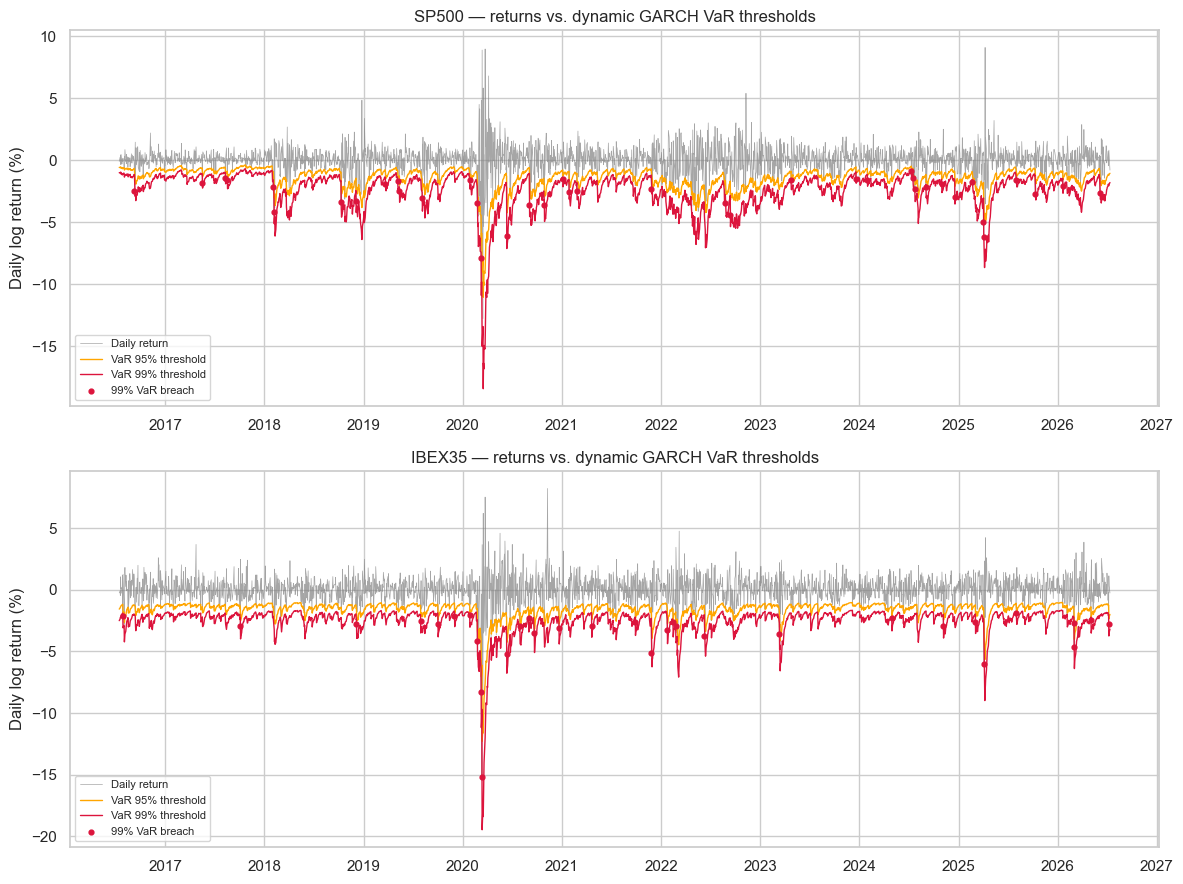

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

for ax, idx in zip(axes, returns_pct.columns):
    r = returns_pct[idx]
    thr95 = var_thresholds[(idx, 0.95)]
    thr99 = var_thresholds[(idx, 0.99)]
    breach99 = r < thr99

    ax.plot(r.index, r, color="grey", linewidth=0.5, alpha=0.7, label="Daily return")
    ax.plot(thr95.index, thr95, color="orange", linewidth=1, label="VaR 95% threshold")
    ax.plot(thr99.index, thr99, color="crimson", linewidth=1, label="VaR 99% threshold")
    ax.scatter(r.index[breach99], r[breach99], color="crimson", s=12, zorder=5, label="99% VaR breach")
    ax.set_title(f"{idx} — returns vs. dynamic GARCH VaR thresholds")
    ax.set_ylabel("Daily log return (%)")
    ax.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()


**Interpretation.** The VaR bands visibly breathe with the market: they sit
close to the return series during the long calm stretches and flare sharply
outward around known stress episodes (most visibly COVID-2020, and to a
lesser extent the 2022 rate/inflation shock) — exactly the dynamic behavior
the model is designed to produce. 99% VaR breaches (red dots) are not
scattered uniformly; several sit close together right around the volatility
spikes. That's expected: a GARCH VaR reacts to *yesterday's* shock, so the
first day or two of a sudden crash — before $\sigma_t$ has had a chance to
widen — is precisely when a breach is most likely, even for a well-specified
model. This clustering-of-breaches question is exactly what Stage 5's
Christoffersen independence test will formally check.


## 5. Expected Shortfall (ES / CVaR)

VaR answers "how bad can a bad day get, at this confidence level" but says
nothing about *how much worse* it could be beyond that threshold. **Expected
Shortfall** fixes this by averaging over the whole tail:

$$
\text{ES}_t(p) = -\left(\mu + \sigma_t \cdot \bar q_p\right), \qquad
\bar q_p = E\!\left[Z \mid Z \le q_p\right]
$$

where $\bar q_p$ is the tail-conditional mean of the standardized Student-t
distribution — always more extreme than $q_p$ itself (ES $\ge$ VaR at the
same confidence level, always, for any continuous loss distribution). ES has
a closed form for the Student-t: for the raw (unscaled) $t_\nu$ quantile
$q_p^{\text{raw}}$ with density $\varphi_\nu$,

$$
\bar q_p^{\text{raw}} = -\frac{\varphi_\nu(q_p^{\text{raw}})}{p} \cdot \frac{\nu + \left(q_p^{\text{raw}}\right)^2}{\nu - 1}
$$

which we then rescale by the same $\sqrt{(\nu-2)/\nu}$ factor used for the
VaR quantile. ES is the tail-risk measure **Basel III's Fundamental Review of
the Trading Book (FRTB)** adopted in place of VaR for regulatory capital,
specifically at the **97.5%** level — chosen because 97.5% ES and 99% VaR
give roughly comparable capital charges for normal-ish tails, while ES
additionally captures how *severe*, not just how *likely*, a tail loss is.


In [6]:
def std_t_es(nu, p):
    raw_q = stats.t.ppf(p, nu)
    raw_phi = stats.t.pdf(raw_q, nu)
    raw_es = -(raw_phi / p) * (nu + raw_q ** 2) / (nu - 1)
    scale = np.sqrt((nu - 2) / nu)
    return raw_es * scale


es_rows = []
for idx in returns_pct.columns:
    res = results[idx]
    mu, nu = res.params["mu"], res.params["nu"]
    sigma = res.conditional_volatility
    for conf in [0.975, 0.99]:
        p = 1 - conf
        es_p = std_t_es(nu, p)
        es_loss = -(mu + sigma * es_p)
        q_p = std_t_quantile(nu, p)
        var_loss = -(mu + sigma * q_p)
        es_rows.append({
            "Index": idx, "Confidence": conf, "nu": nu,
            "Mean VaR": var_loss.mean(), "Mean ES": es_loss.mean(),
            "Max ES": es_loss.max(), "Max ES date": es_loss.idxmax(),
        })

es_df = pd.DataFrame(es_rows).set_index(["Index", "Confidence"])
es_df.round(3)


nu  Mean VaR  Mean ES  Max ES Max ES date
Index  Confidence                                              
SP500  0.975       5.093     1.842    2.540  19.260  2020-03-17
       0.990       5.093     2.427    3.222  24.313  2020-03-17
IBEX35 0.975       7.006     1.997    2.622  20.040  2020-03-13
       0.990       7.006     2.545    3.213  24.484  2020-03-13

**Interpretation.** As required by theory, ES is larger than VaR at every
matching confidence level (e.g. for the S&P 500, mean 99% ES $\approx 3.22\%$
vs. mean 99% VaR $\approx 2.43\%$ — roughly a third larger) — the gap is the
"how much worse than the threshold" information VaR alone throws away. The
gap is wider for the S&P 500 than the IBEX 35 at every confidence level,
which lines up directly with Stage 3's finding that the S&P 500's
standardized residuals have fatter tails ($\nu \approx 5.1$ vs. $\nu \approx
7.0$ for the IBEX): a fatter tail means the average loss *given* a breach is
disproportionately worse than the breach threshold itself, so ES penalizes
the fatter-tailed market by relatively more than VaR does. Both indices'
worst-case ES lands on the COVID-2020 crash, consistent with the volatility
plot from Stage 3.


## 6. EWMA (RiskMetrics) baseline

The classic, model-free alternative: **exponentially weighted moving average
(EWMA)** volatility, the RiskMetrics standard,

$$
\hat\sigma_t^2 = \lambda\, \hat\sigma_{t-1}^2 + (1-\lambda)\, r_{t-1}^2, \qquad \lambda = 0.94
$$

This is a GARCH(1,1) with $\omega$ fixed at 0 and $\alpha+\beta$ fixed at
exactly 1 (i.e. an IGARCH special case) — no maximum-likelihood fitting
required, just a single smoothing constant chosen once, decades ago, by
RiskMetrics for daily data. The *textbook* RiskMetrics VaR formula pairs
this volatility with a **normal** quantile and a **zero mean** (the daily
mean is negligible relative to volatility at this horizon):

$$
\text{VaR}_t^{\text{EWMA, textbook}}(p) = -\hat\sigma_t \cdot z_p
$$

**We deliberately do not use that textbook formula for the comparison in
this notebook.** If we did, a difference in breach rates between GARCH and
EWMA would be tangled up from two separate sources — a different
*volatility estimator* **and** a different *tail-distribution assumption* —
and there would be no way to tell which one actually drove the result (the
mean term is a much smaller effect than the distribution choice, since
$\mu$ is tiny relative to $\sigma_t$, but the same logic applies: use the
same $\mu$ for both, or the comparison isn't clean). To isolate the
volatility estimator — the thing this notebook is actually trying to
evaluate — we pair the EWMA volatility with the **same constant mean $\mu$
and the same Student-t quantile (same fitted $\nu$)** used for the GARCH
VaR:

$$
\text{VaR}_t^{\text{EWMA}}(p) = -\left(\mu + \hat\sigma_t \cdot q_p\right)
$$

reusing the $\mu$, $\nu$ and $q_p$ from that index's preferred GARCH model.
This means any gap between GARCH-VaR and EWMA-VaR in Section 7 is
attributable specifically to *how the two methods estimate volatility*, not
to which mean or tail shape they assume — the genuinely "honest simple
benchmark" question this notebook set out to ask.


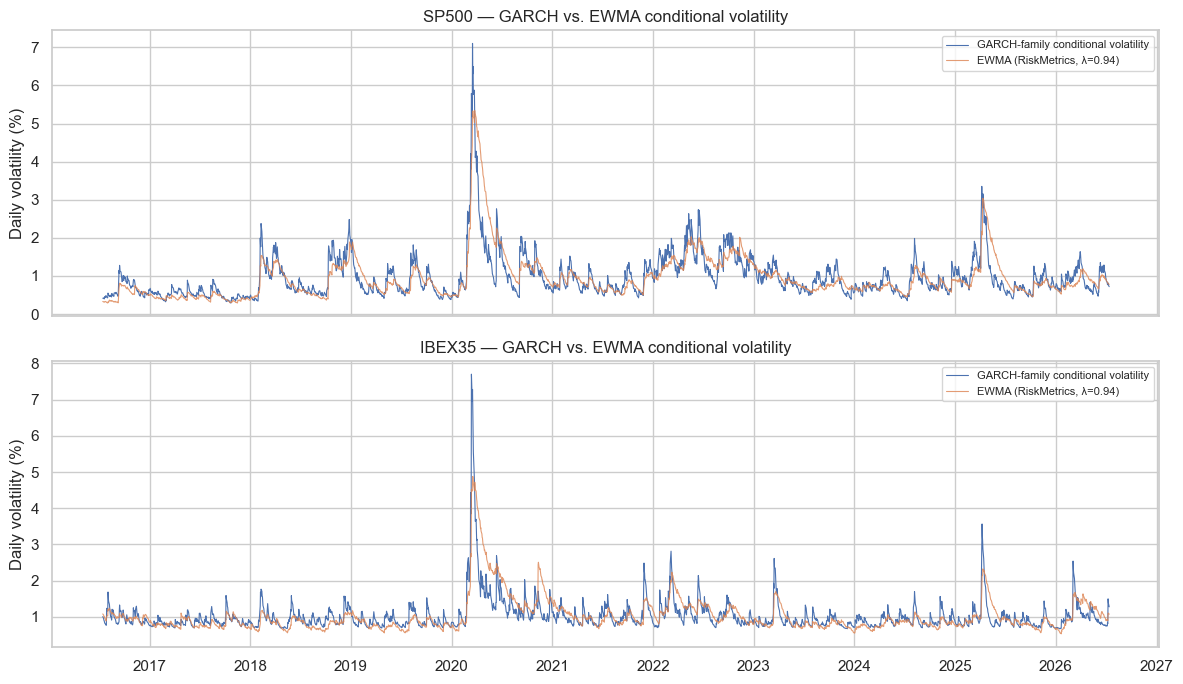

In [7]:
def ewma_volatility(returns, lam=0.94, seed_window=30):
    var = np.empty(len(returns))
    var[0] = returns.iloc[:seed_window].var()
    for t in range(1, len(returns)):
        var[t] = lam * var[t - 1] + (1 - lam) * returns.iloc[t - 1] ** 2
    return pd.Series(np.sqrt(var), index=returns.index)


ewma_vol = {idx: ewma_volatility(returns_pct[idx]) for idx in returns_pct.columns}

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, idx in zip(axes, returns_pct.columns):
    ax.plot(results[idx].conditional_volatility, label="GARCH-family conditional volatility", linewidth=0.8)
    ax.plot(ewma_vol[idx], label="EWMA (RiskMetrics, λ=0.94)", linewidth=0.8, alpha=0.8)
    ax.set_title(f"{idx} — GARCH vs. EWMA conditional volatility")
    ax.set_ylabel("Daily volatility (%)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Interpretation.** The two volatility series track each other closely most
of the time — unsurprising, since both are exponentially-weighted functions
of past squared shocks and $\lambda=0.94$ is not far from the fitted GARCH
persistence terms from Stage 3. The visible differences are exactly where
they should be: EWMA reacts slightly faster to a fresh shock (no $\omega$
floor pulling it back, and a fixed rather than estimated decay), so its
spikes are a touch sharper but also fade a little quicker than the
GARCH-family curve. Because Section 7's comparison now holds the mean and
tail distribution fixed across both methods (Section 6), these volatility
differences — not a differing tail assumption — are exactly what drives any
remaining gap in breach rates.


## 7. Comparison: breach counts

For each index and confidence level, we compare the number of actual VaR
breaches produced by the GARCH model against the **fair** EWMA benchmark
(same $\mu$, same Student-t $q_p$ — see Section 6), next to the number we'd
*expect* under a perfectly calibrated model: $n \times p$. This is a first,
informal, **in-sample** look — **formal statistical validation with a
genuine out-of-sample backtest (the Kupiec proportion-of-failures test and
the Christoffersen independence test) is the subject of Stage 5.** Here we
only observe counts; we don't yet test whether any excess is statistically
significant, and these models still benefit from having seen the whole
sample when they were fit.


In [8]:
compare_rows = []
for idx in returns_pct.columns:
    res = results[idx]
    mu, nu = res.params["mu"], res.params["nu"]
    sigma = res.conditional_volatility
    r = returns_pct[idx]
    n = len(r)

    for conf in [0.95, 0.99]:
        p = 1 - conf
        q_p = std_t_quantile(nu, p)
        garch_thr = mu + sigma * q_p
        ewma_thr = mu + ewma_vol[idx] * q_p

        garch_breaches = int((r < garch_thr).sum())
        ewma_breaches = int((r < ewma_thr).sum())

        compare_rows.append({
            "Index": idx, "Confidence": conf, "n": n,
            "Expected breaches": n * p,
            "GARCH breaches": garch_breaches, "GARCH rate": garch_breaches / n,
            "EWMA breaches": ewma_breaches, "EWMA rate": ewma_breaches / n,
            "Mean GARCH VaR": (-garch_thr).mean(), "Mean EWMA VaR": (-ewma_thr).mean(),
        })

compare_df = pd.DataFrame(compare_rows).set_index(["Index", "Confidence"])
compare_df.round(3)


n  Expected breaches  GARCH breaches  GARCH rate  \
Index  Confidence                                                        
SP500  0.95        2579             128.95             164       0.064   
       0.99        2579              25.79              40       0.016   
IBEX35 0.95        2579             128.95             157       0.061   
       0.99        2579              25.79              32       0.012   

                   EWMA breaches  EWMA rate  Mean GARCH VaR  Mean EWMA VaR  
Index  Confidence                                                           
SP500  0.95                  183      0.071           1.431          1.415  
       0.99                   51      0.020           2.427          2.400  
IBEX35 0.95                  177      0.069           1.590          1.586  
       0.99                   44      0.017           2.545          2.540

**Interpretation.** With the comparison now fair (same $\mu$, same Student-t
$\nu$ for both methods), **GARCH beats EWMA at both confidence levels for
both indices** — a cleaner result than it first appears, and worth
unpacking, because a *textbook* EWMA comparison (normal quantile, zero mean)
would have been actively misleading in one direction:

- **At 99%: GARCH is closer to nominal for both indices.** S&P 500: 40 GARCH
  breaches (1.55%) vs. 51 EWMA breaches (1.98%) against an expected 26
  (1.00%). IBEX 35: 32 GARCH breaches (1.24%) vs. 44 EWMA breaches (1.71%).
- **At 95%: GARCH is now also closer to nominal for both indices** — S&P
  500: 164 GARCH breaches (6.36%) vs. 183 EWMA breaches (7.10%); IBEX 35: 157
  GARCH breaches (6.09%) vs. 177 EWMA breaches (6.86%).

Had we instead used the textbook EWMA formula (normal quantile, zero mean —
see Section 6), the 95% comparison would have come out the other way round:
EWMA would show *fewer* breaches than GARCH (roughly 143 vs. 164 for the S&P
500), making EWMA look like the better-calibrated model at that level. That
reversal is the tell-tale sign the textbook comparison isn't measuring what
it claims to: **it measures the normal-vs-Student-t distribution choice, not
the EWMA-vs-GARCH volatility estimator.** The mechanism is a well-known
property of unit-variance heavy-tailed distributions — the standardized
Student-t quantile *crosses* the normal quantile somewhere around the
high-90s percentile. Concretely, for $\nu \approx 5$: at $p=0.05$ the
standardized Student-t quantile ($\approx -1.56$) is *less* extreme than the
normal quantile ($\approx -1.64$), but at $p=0.01$ it flips and becomes
*more* extreme ($\approx -2.60$ vs. $-2.33$). So a normal quantile makes the
textbook-EWMA threshold *artificially wide* at 95% (fewer breaches,
flattering EWMA) and *artificially tight* at 99% (more breaches, penalizing
EWMA) — for reasons that have nothing to do with EWMA's volatility estimate
itself.

Once that confound is removed, the comparison is unambiguous: **GARCH's
volatility estimate is better calibrated than EWMA's at both confidence
levels**, though the margin is modest at 95% (164 vs. 183, both still
over-breaching the 129 expected) and more material at 99% (40 vs. 51 for the
S&P 500). This is a genuinely fairer conclusion than a naive normal-quantile
EWMA benchmark would give — but it is still an **in-sample** result
(Section 4's caveat applies here too), so treat "GARCH wins" as a working
hypothesis to be tested properly, out-of-sample, in Stage 5 — not yet a
validated finding.


## 8. Summary

1. **Parametric GARCH VaR** is genuinely dynamic — it widens sharply around
   COVID-2020 and other stress episodes and narrows in calm periods, unlike a
   static historical VaR. This dynamic *shape* is real regardless of the
   caveat below.
2. **Expected Shortfall** is materially larger than VaR at every matching
   confidence level, and the ES-VaR gap is wider for the S&P 500 than the
   IBEX 35 — a direct echo of the S&P's fatter Student-t tails found in
   Stage 3.
3. **The GARCH-vs-EWMA comparison must hold the mean and tail distribution
   fixed to be meaningful.** With a fair (same $\mu$, same Student-t $\nu$)
   comparison, GARCH's breach rate is closer to nominal than EWMA's at
   *both* 95% and 99% for both indices — not just at 99%, as a naive
   normal-quantile EWMA benchmark would suggest.
4. **Every result in this notebook is in-sample.** All models were fit once
   on the full ~10-year sample, so this is an exploration of model fit, not
   a validated out-of-sample forecast — the look-ahead bias means these
   breach rates are likely *more* favorable than genuine real-time
   performance would be.

**Next stage:** formally backtest these VaR models **out-of-sample** —
refitting on an expanding window using only data available at each point in
time — with the Kupiec proportion-of-failures test (are breach rates
statistically consistent with the nominal confidence level?) and the
Christoffersen independence test (are breaches clustered in time, or
scattered as they should be?).
